<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/Chatbot_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
load_dotenv()

False

In [9]:
from google.colab import userdata
llm=ChatGroq(
    temperature=0,
    groq_api_key=userdata.get('Groq'),
    model_name="qwen/qwen3-32b",
    verbose=True
)

In [10]:
class ChatState(TypedDict):
  messages:Annotated[list[BaseMessage],add_messages]

In [11]:
def chat_node(state:ChatState):
  mess=llm.invoke(state['messages'])
  state['messages'].append(mess)

In [12]:
graph=StateGraph(ChatState)

In [14]:
graph.add_node('ChatNode',chat_node)

In [15]:
graph.add_edge(START,'ChatNode')
graph.add_edge('ChatNode',END)

In [16]:
workflow=graph.compile()

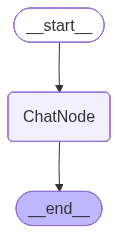

In [17]:
workflow

In [25]:
workflow.invoke({'messages':[HumanMessage(content='What is the capital of india')]})

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='365eb417-6972-4031-bb01-9d17a17558fb'),
  AIMessage(content='<think>\nOkay, so the user is asking, "What is the capital of India?" Let me start by recalling what I know about India\'s capital. I remember that New Delhi is the capital, but I should make sure I\'m not confusing it with Delhi. Wait, Delhi is a city, and New Delhi is a part of it, right? Let me think.\n\nIndia is a country in South Asia. The capital city is where the government is located. Before independence, the capital was Calcutta, but then it was moved to Delhi. After independence in 1947, New Delhi became the capital. So, New Delhi is the correct answer. But I should explain the difference between Delhi and New Delhi to avoid confusion. Delhi is a larger area, and New Delhi is the specific part that serves as the capital. Also, Delhi is a union territory, and New Delhi is the capital city within that ter

In [26]:
result = workflow.invoke({
    "messages": [HumanMessage(content="What is the capital of India")]
})

result["messages"][-1].content


"<think>\nOkay, so I need to figure out what the capital of India is. Let me start by recalling what I know. I remember that India is a country in South Asia. I think the capital might be New Delhi, but I'm not entirely sure. Wait, there's also Delhi, which is a city. Is New Delhi a separate city within Delhi? Maybe I should check that.\n\nI know that in some countries, the capital is a city that's part of a larger metropolitan area. For example, Washington, D.C., is the capital of the United States, but it's a separate district from the city of Washington. So maybe New Delhi is similar. Let me think. I've heard of New Delhi being referred to as the capital, and Delhi as the surrounding area. \n\nI should also consider if there's any confusion with other cities. Sometimes people might confuse the capital with a major city like Mumbai or Bangalore, but I think those are more known for being economic or tech hubs. Mumbai is the financial capital, right? So the actual political capital is